# Notebook 2 — Comprensión y EDA

**Proyecto Integrador - Módulo 5 - Henry**
**Pipeline MLOps - Predicción de Pago a Tiempo**
**Versión:** V1.0.1 (Avance 1, parte 2 de 2)

---

## Objetivo del notebook

Análisis Exploratorio de Datos (EDA) exhaustivo del dataset limpio producido por `Cargar_datos.ipynb`. Cubre:

1. **Exploración inicial** — caracterización de variables, revisión de nulos, eliminación de irrelevantes.
2. **Análisis univariable** — distribuciones, estadísticas descriptivas, formas de distribución.
3. **Análisis bivariable** — relaciones de cada variable con el target `Pago_atiempo`.
4. **Análisis multivariable** — correlaciones, pairplots, multicolinealidad.
5. **Detección de leakage** — bandera roja crítica para la validez del modelo.
6. **Reglas de validación** — contrato de datos para producción (lo consume el deploy).
7. **Features derivadas propuestas** — atributos calculados que pueden mejorar el modelo.



## 1. Imports y carga del dataset limpio

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Estética
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")

pandas: 2.3.3
seaborn: 0.13.2


In [2]:
# Cargar configuración
with open('config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

TARGET_VAR = config['target_variable']
DATA_PROC = Path('../../data_processed/dataset_limpio.parquet')

df = pd.read_parquet(DATA_PROC)

# Re-aplicar orden categórico ordinal a tendencia_ingresos
# (parquet preserva 'category' pero pierde 'ordered=True')
df['tendencia_ingresos'] = pd.Categorical(
    df['tendencia_ingresos'],
    categories=['Decreciente', 'Estable', 'Creciente'],
    ordered=True
)
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Target:  {TARGET_VAR} (binario)")
df.head(3)

Dataset: 10,763 filas × 23 columnas
Target:  Pago_atiempo (binario)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0


## 2. Caracterización: tabla resumen ejecutiva

Tabla maestra con la naturaleza de cada variable. 

In [3]:
# Construir tabla de caracterización completa
def caracterizar_variable(s, nombre):
    n_unicos = s.nunique(dropna=True)
    n_nulos = s.isnull().sum()
    pct_nulos = n_nulos / len(s) * 100

    tipo = str(s.dtype)
    if pd.api.types.is_datetime64_any_dtype(s):
        familia = 'Temporal'
    elif isinstance(s.dtype, pd.CategoricalDtype):
        familia = 'Categórica ordinal' if s.cat.ordered else 'Categórica nominal'
    elif pd.api.types.is_integer_dtype(s):
        familia = 'Numérica discreta'
    elif pd.api.types.is_float_dtype(s):
        familia = 'Numérica continua'
    else:
        familia = 'Otro'

    if nombre == TARGET_VAR:
        familia = 'Target (dicotómica)'

    return {
        'variable': nombre,
        'familia': familia,
        'dtype': tipo,
        'n_unicos': n_unicos,
        'n_nulos': n_nulos,
        '%_nulos': round(pct_nulos, 2)
    }

resumen = pd.DataFrame([caracterizar_variable(df[c], c) for c in df.columns])
print(f"Total variables: {len(resumen)}")
print(f"  Numéricas continuas:  {(resumen.familia=='Numérica continua').sum()}")
print(f"  Numéricas discretas:  {(resumen.familia=='Numérica discreta').sum()}")
print(f"  Categóricas nominales:{(resumen.familia=='Categórica nominal').sum()}")
print(f"  Categóricas ordinales:{(resumen.familia=='Categórica ordinal').sum()}")
print(f"  Temporales:           {(resumen.familia=='Temporal').sum()}")
print(f"  Target:               {(resumen.familia=='Target (dicotómica)').sum()}")
resumen

Total variables: 23
  Numéricas continuas:  8
  Numéricas discretas:  10
  Categóricas nominales:2
  Categóricas ordinales:1
  Temporales:           1
  Target:               1


,variable,familia,dtype,n_unicos,n_nulos,%_nulos
0,tipo_credito,Categórica nominal,category,6,0,0.00
1,fecha_prestamo,Temporal,datetime64[ns],10758,0,0.00
2,capital_prestado,Numérica continua,float64,7306,0,0.00
3,plazo_meses,Numérica discreta,Int64,18,0,0.00
4,edad_cliente,Numérica discreta,Int64,54,0,0.00
5,tipo_laboral,Categórica nominal,category,2,0,0.00
6,salario_cliente,Numérica discreta,int64,1385,0,0.00
7,total_otros_prestamos,Numérica discreta,int64,1538,0,0.00
8,cuota_pactada,Numérica discreta,int64,9836,0,0.00
9,puntaje,Numérica continua,float64,248,0,0.00


## 3. Revisión de nulos (visualización)

Confirmamos lo que ya sabemos del notebook 1: nulos solo en `promedio_ingresos_datacredito` y `tendencia_ingresos`, y son **las mismas filas**.

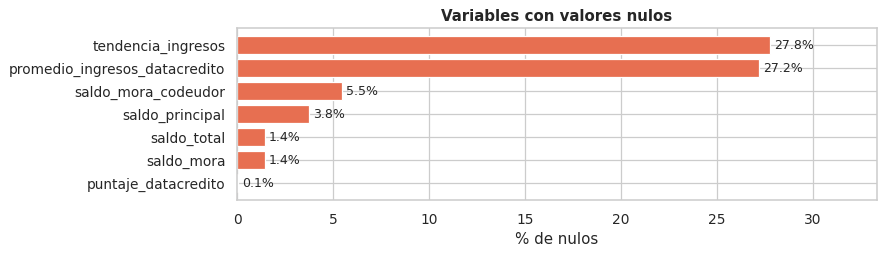


[Hallazgo confirmado]: las dos variables nulificadas (~27.8%) representan
clientes sin historial en datacrédito. Esto NO es ruido: es información sociológica.


In [ ]:
nulos_pct = df.isnull().sum() / len(df) * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(nulos_pct.index, nulos_pct.values, color='#e76f51')
for i, v in enumerate(nulos_pct.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de nulos')
ax.set_title('Variables con valores nulos', fontsize=12, fontweight='bold')
ax.set_xlim(0, nulos_pct.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"\n[Hallazgo confirmado]: las dos variables nulificadas (~{nulos_pct.iloc[-1]:.1f}%) representan")
print("clientes sin historial en datacrédito. Esto NO es ruido, es información.")

## 4. Distribución del target

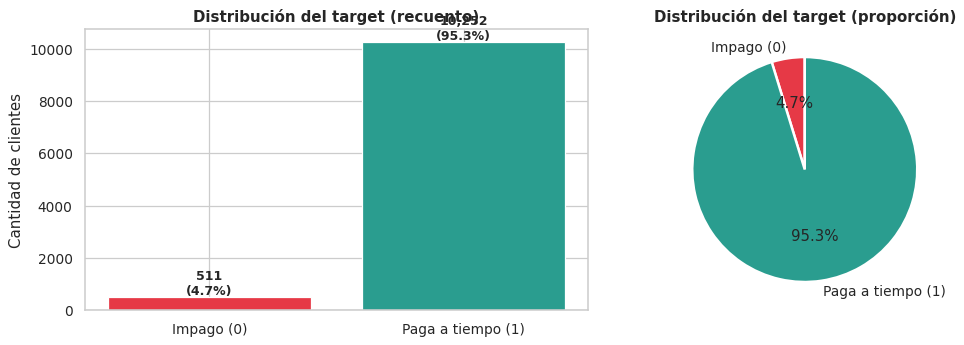


Desbalance: 1 impago por cada 20.1 pagos a tiempo
Implicancia: accuracy es métrica engañosa. Usamos ROC-AUC + F1 sobre clase 0.


In [5]:
distr = df[TARGET_VAR].value_counts().sort_index()
distr_pct = df[TARGET_VAR].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = ['#e63946', '#2a9d8f']
axes[0].bar(['Impago (0)', 'Paga a tiempo (1)'], distr.values, color=colors)
for i, v in enumerate(distr.values):
    axes[0].text(i, v + 100, f'{v:,}\n({distr_pct.iloc[i]:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribución del target (recuento)', fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')

# Pie
axes[1].pie(distr.values, labels=['Impago (0)', 'Paga a tiempo (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribución del target (proporción)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDesbalance: 1 impago por cada {distr[1]/distr[0]:.1f} pagos a tiempo")
print("Implicancia: accuracy es métrica engañosa. Usamos ROC-AUC + F1 sobre clase 0.")

---

# ANÁLISIS UNIVARIABLE

## 5. Estadísticas descriptivas — Variables numéricas

In [6]:
NUMERICAS_CONT = [
    'capital_prestado', 'salario_cliente', 'total_otros_prestamos',
    'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
    'promedio_ingresos_datacredito'
]
NUMERICAS_DISC = [
    'plazo_meses', 'edad_cliente', 'cant_creditosvigentes', 'huella_consulta',
    'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal'
]
NUMERICAS = NUMERICAS_CONT + NUMERICAS_DISC

descripcion = df[NUMERICAS].describe().T
descripcion['skewness'] = df[NUMERICAS].skew()
descripcion['kurtosis'] = df[NUMERICAS].kurtosis()
descripcion['IQR'] = descripcion['75%'] - descripcion['25%']
descripcion['rango'] = descripcion['max'] - descripcion['min']
descripcion['coef_variacion'] = (descripcion['std'] / descripcion['mean']).abs()

cols_orden = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
              'IQR', 'rango', 'skewness', 'kurtosis', 'coef_variacion']
descripcion[cols_orden].round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,rango,skewness,kurtosis,coef_variacion
capital_prestado,10763.0,2434315.001319,1909642.758997,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1860009.0,41084152.8,3.72,35.32,0.784468
salario_cliente,10763.0,17216431.459909,355476717.603482,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,2875808.0,22000000000.0,43.78,2211.23,20.647526
total_otros_prestamos,10763.0,6238869.648518,118418316.941069,0.0,500000.0,1000000.0,2000000.0,6787675263.0,1500000.0,6787675263.0,38.46,1719.28,18.980733
cuota_pactada,10763.0,243617.406671,210493.694608,23944.0,121041.5,182863.0,287833.5,3816752.0,166792.0,3792808.0,3.79,26.65,0.864034
puntaje,10763.0,91.170036,16.465441,-38.00999,95.227787,95.227787,95.227787,95.227787,0.0,133.237777,-4.87,24.08,0.180601
puntaje_datacredito,10757.0,780.790834,104.878031,-7.0,757.0,791.0,825.0,999.0,68.0,1006.0,-5.64,39.44,0.134323
saldo_mora,10607.0,7.746017,225.955117,0.0,0.0,0.0,0.0,12534.0,0.0,12534.0,40.57,1845.71,29.170492
saldo_total,10607.0,45937.408127,106269.789916,0.0,2898.0,16178.0,52982.0,5116066.0,50084.0,5116066.0,20.2,789.17,2.313361
saldo_principal,10358.0,40346.168179,71242.440332,0.0,2690.0,14442.5,47632.25,1562285.0,44942.25,1562285.0,5.05,51.06,1.76578
saldo_mora_codeudor,10173.0,0.260002,21.772917,0.0,0.0,0.0,0.0,2145.0,0.0,2145.0,94.97,9279.82,83.741354


### Interpretación de las estadísticas descriptivas

**Lectura clave** (skewness y kurtosis):
- `skewness ≈ 0`: distribución simétrica (gaussiana ideal).
- `skewness > 1`: cola larga a la derecha (típico de ingresos y montos).
- `kurtosis > 3`: distribución más puntiaguda que normal (presencia de outliers).
- `coef_variacion > 1`: alta dispersión relativa.

**[Observado]** Variables con cola larga a la derecha (skewness >> 0): `capital_prestado`, `salario_cliente`, `saldo_mora`, `saldo_total`. Esto sugiere que **una transformación logarítmica** podría ayudar a varios modelos (especialmente lineales).

**[Observado]** Variables de saldo (`saldo_mora`, `saldo_total`, etc.) tienen mucho 0 (mediana baja) pero algunos valores extremos altos → patrón típico de portafolio crediticio.

## 6. Distribuciones — Histogramas + Boxplots de variables continuas

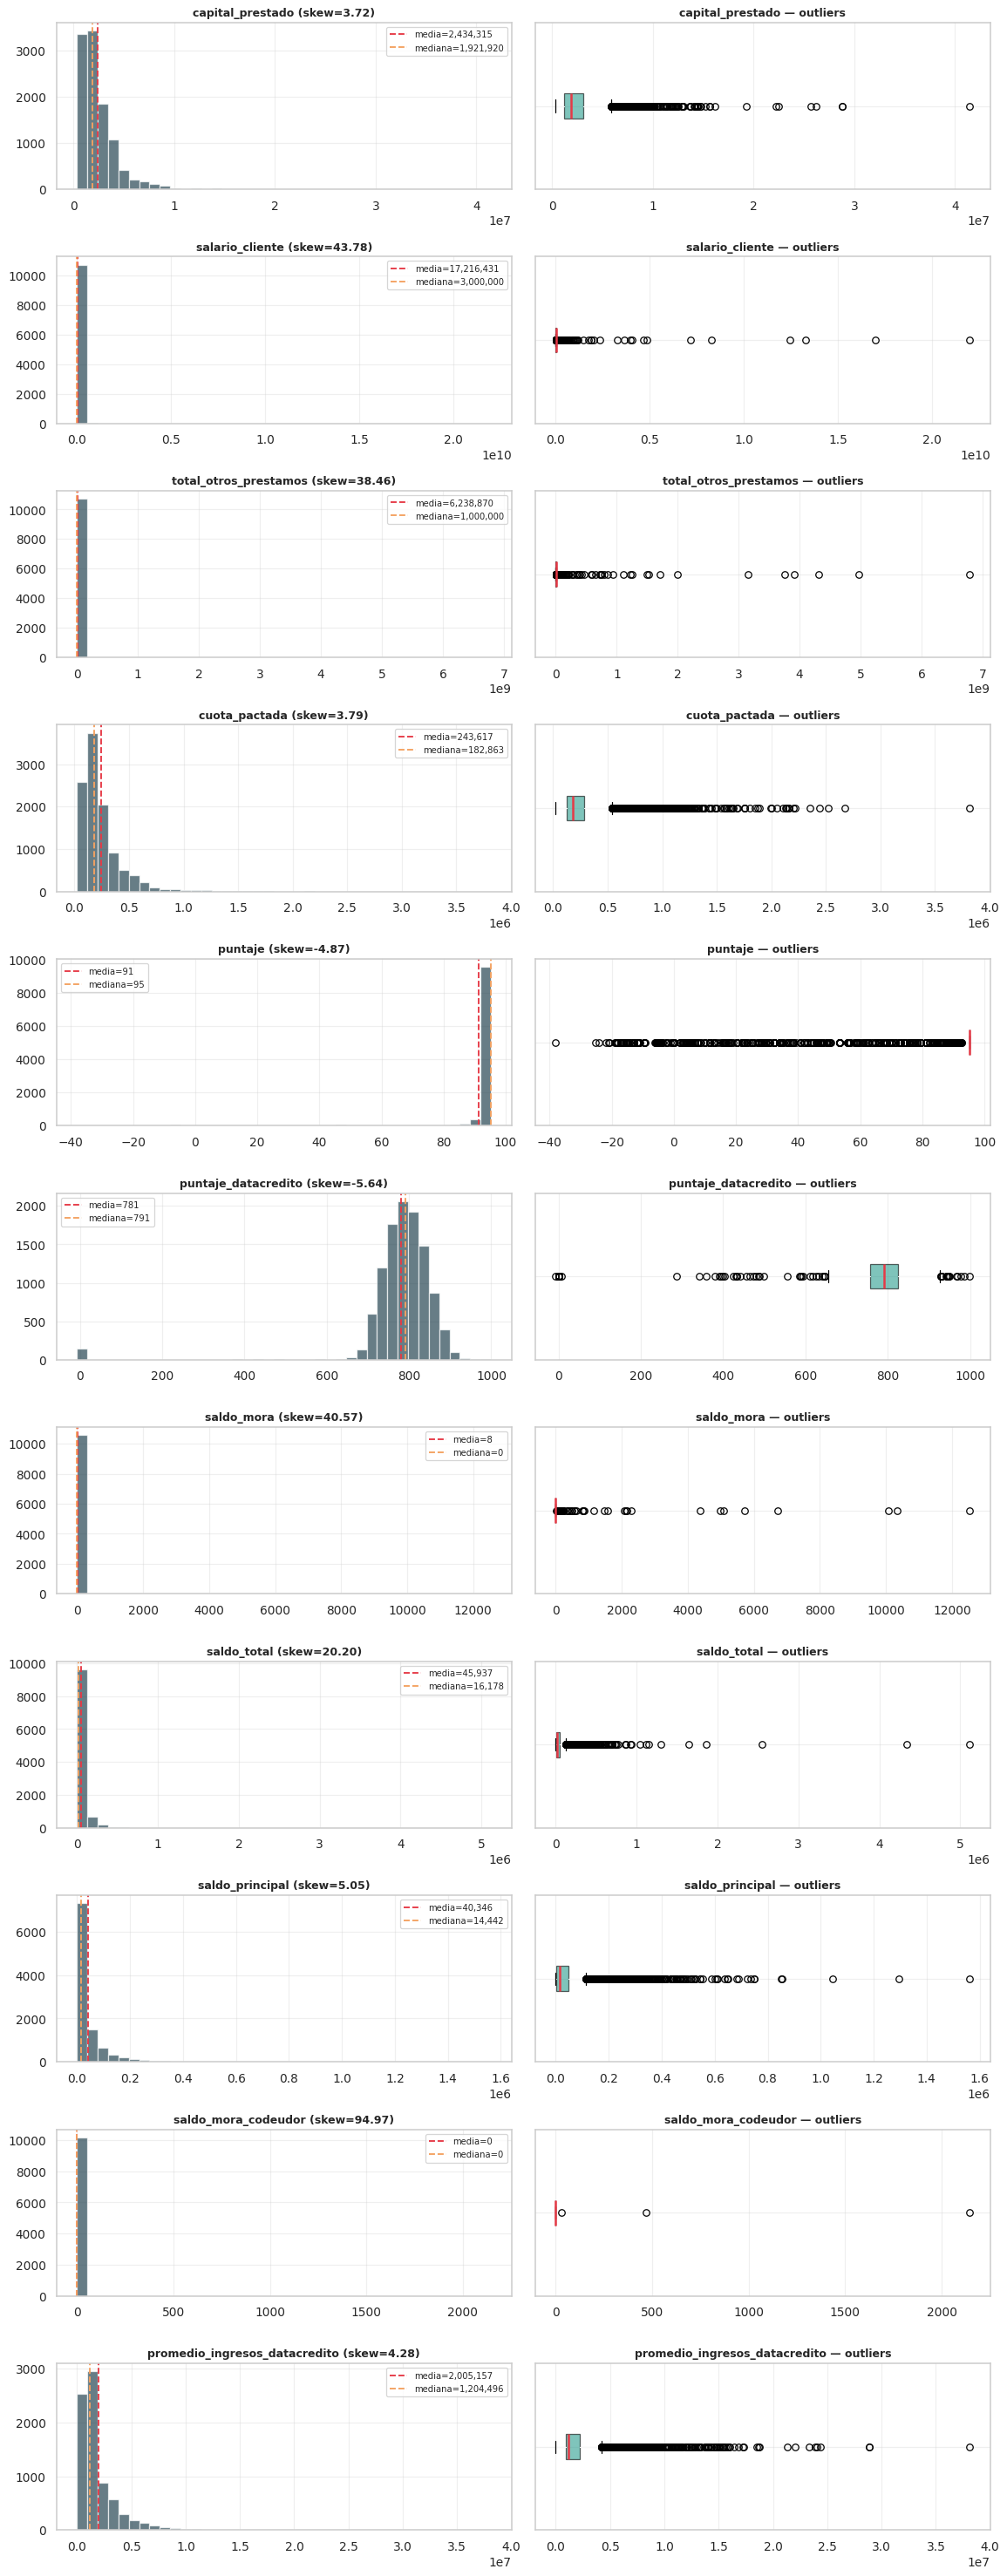

In [7]:
fig, axes = plt.subplots(len(NUMERICAS_CONT), 2, figsize=(13, 3 * len(NUMERICAS_CONT)))

for i, col in enumerate(NUMERICAS_CONT):
    # Histograma
    ax_hist = axes[i, 0]
    df[col].dropna().hist(bins=40, ax=ax_hist, color='#264653', alpha=0.7, edgecolor='white')
    media = df[col].mean()
    mediana = df[col].median()
    ax_hist.axvline(media, color='#e63946', linestyle='--', linewidth=1.5, label=f'media={media:,.0f}')
    ax_hist.axvline(mediana, color='#f4a261', linestyle='--', linewidth=1.5, label=f'mediana={mediana:,.0f}')
    ax_hist.set_title(f'{col} (skew={df[col].skew():.2f})', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    # Boxplot
    ax_box = axes[i, 1]
    df[col].dropna().to_frame().boxplot(ax=ax_box, vert=False, patch_artist=True,
                                          boxprops=dict(facecolor='#2a9d8f', alpha=0.6),
                                          medianprops=dict(color='#e63946', linewidth=2))
    ax_box.set_title(f'{col} — outliers', fontsize=10, fontweight='bold')
    ax_box.set_yticklabels([''])
    ax_box.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**[Observado] Patrones de las distribuciones:**

- `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada`: distribuciones **fuertemente sesgadas a la derecha** (cola larga). Típico de variables monetarias.
- `puntaje` y `puntaje_datacredito`: distribuciones **cercanas a normal** o con sesgo leve. Buenas candidatas para usar tal cual.
- `saldo_mora`, `saldo_total`, `saldo_principal`: **concentración masiva en 0** con outliers extremos. Esto es esperable: la mayoría no tiene mora activa.
- `saldo_mora_codeudor`: casi siempre 0, lo que sugiere que **pocos clientes tienen codeudor con mora**. Podría convertirse en una variable binaria `tiene_codeudor_con_mora`.



## 7. Distribuciones — Variables discretas

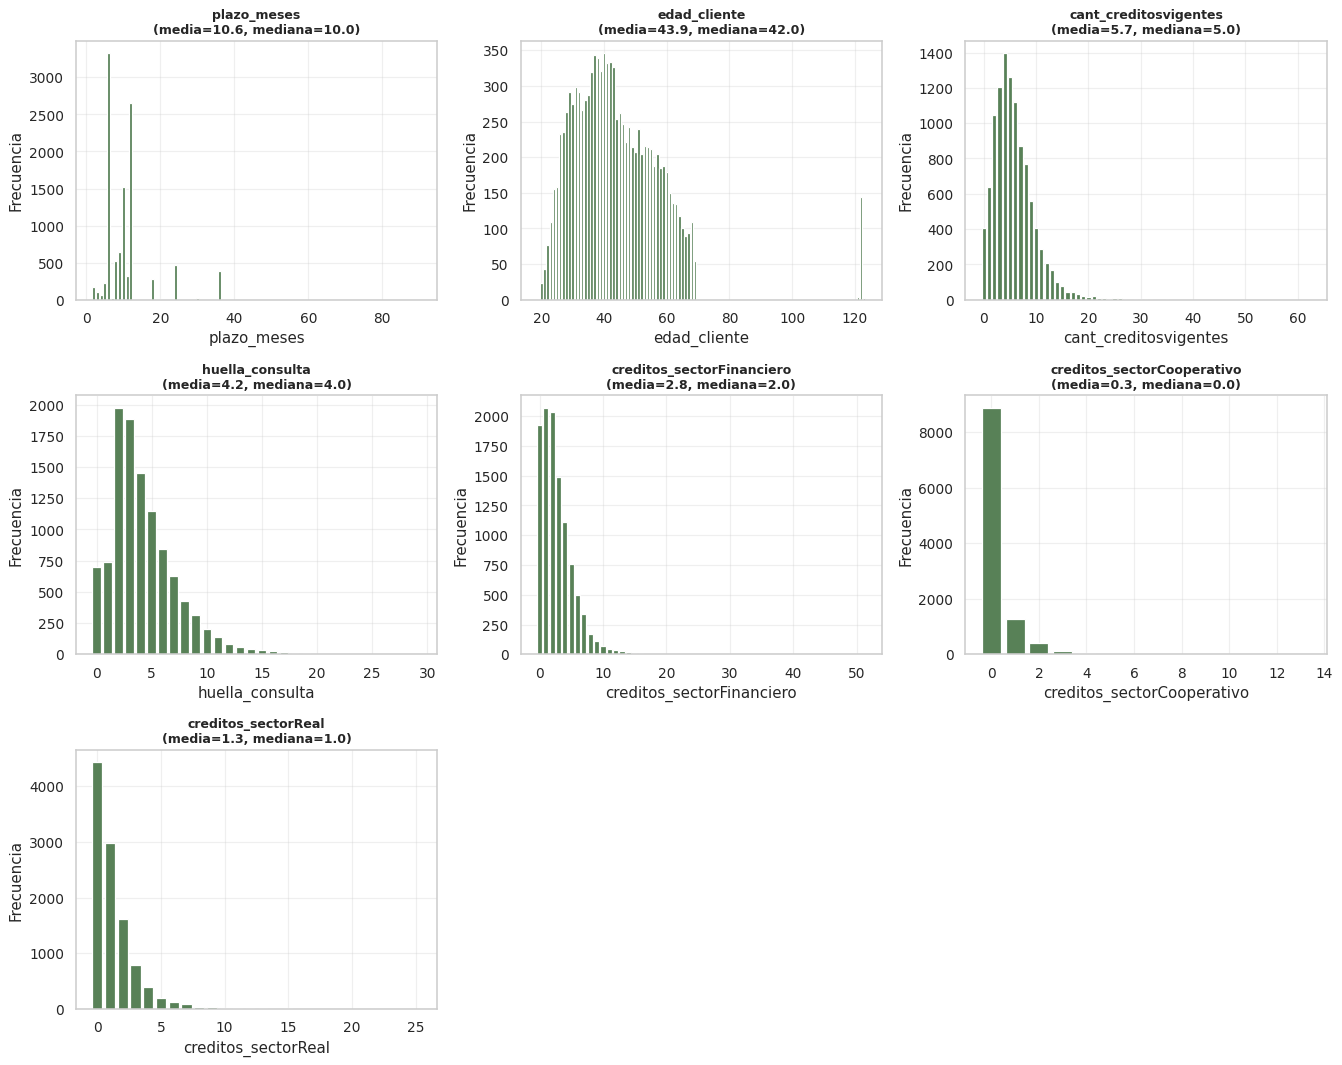

In [8]:
fig, axes = plt.subplots((len(NUMERICAS_DISC) + 2) // 3, 3, figsize=(15, 4 * ((len(NUMERICAS_DISC) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(NUMERICAS_DISC):
    ax = axes[i]
    valores = df[col].dropna().value_counts().sort_index()
    ax.bar(valores.index.astype(int), valores.values, color='#588157', edgecolor='white')
    ax.set_title(f'{col}\n(media={df[col].mean():.1f}, mediana={df[col].median():.1f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)

# Esconder ejes sobrantes
for j in range(len(NUMERICAS_DISC), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**[Observado]:**
- `edad_cliente`: distribución mayormente uniforme entre 25-60, picos en valores redondos (probable redondeo).
- `plazo_meses`: pocos valores discretos (6, 10, 11, 12, 24, 36, 48, 60...) — comportamiento típico de productos crediticios estandarizados.
- `cant_creditosvigentes`, `huella_consulta`: distribuciones con cola, mayoría con valores bajos.
- `creditos_sectorFinanciero/Cooperativo/Real`: muchas filas en 0, alguna actividad puntual.

## 8. Distribuciones — Variables categóricas

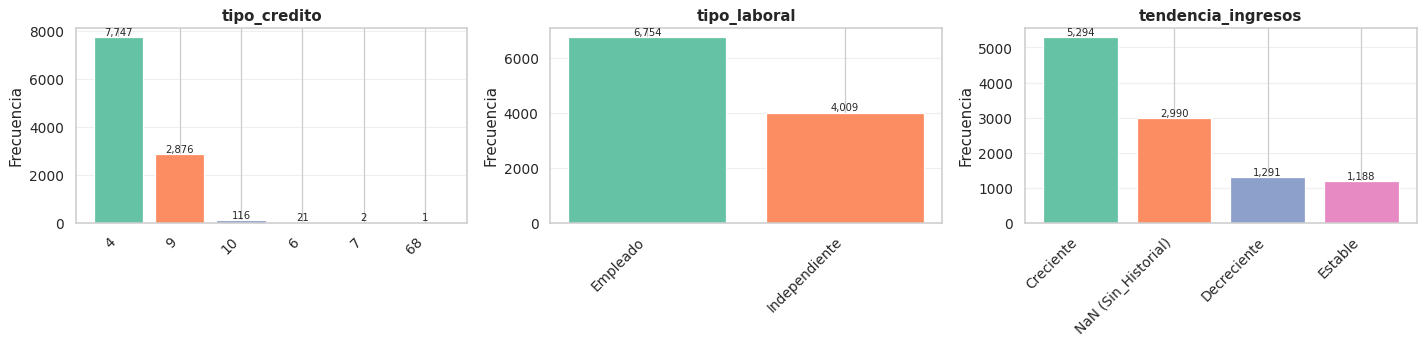


tipo_credito:
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1

tipo_laboral:
tipo_laboral
Empleado         6754
Independiente    4009

tendencia_ingresos:
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188


In [9]:
CATEGORICAS = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(CATEGORICAS):
    ax = axes[i]
    counts = df[col].value_counts(dropna=False).sort_values(ascending=False)

    # Reemplazar NaN por 'Sin_Historial' para visualizar
    labels = [str(x) if not pd.isna(x) else 'NaN (Sin_Historial)' for x in counts.index]

    colors = sns.color_palette("Set2", len(counts))
    ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    for j, v in enumerate(counts.values):
        ax.text(j, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=8)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Mostrar value_counts en texto también
for col in CATEGORICAS:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())

**[Observado]:**
- `tipo_credito`: hay ~10 categorías codificadas. Una de ellas domina pero las demás tienen volumen razonable.
- `tipo_laboral`: distribución entre Empleado e Independiente. Los porcentajes nos dicen el mix de la cartera.
- `tendencia_ingresos`: la mayoría tiene tendencia 'Creciente' o 'Estable'. La categoría 'NaN' (Sin_Historial) representa el ~14% que ya identificamos.

---

# ANÁLISIS BIVARIABLE (vs target Pago_atiempo)

## 9. Variables numéricas vs Pago_atiempo

Para cada variable numérica, comparamos su distribución entre quienes pagan y quienes no.

/sessions/serene-amazing-davinci/tmp/ipykernel_8/2720349300.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-davinci/tmp/ipykernel_8/2720349300.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-davinci/tmp/ipykernel_8/2720349300.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
/sessions/serene-amazing-dav

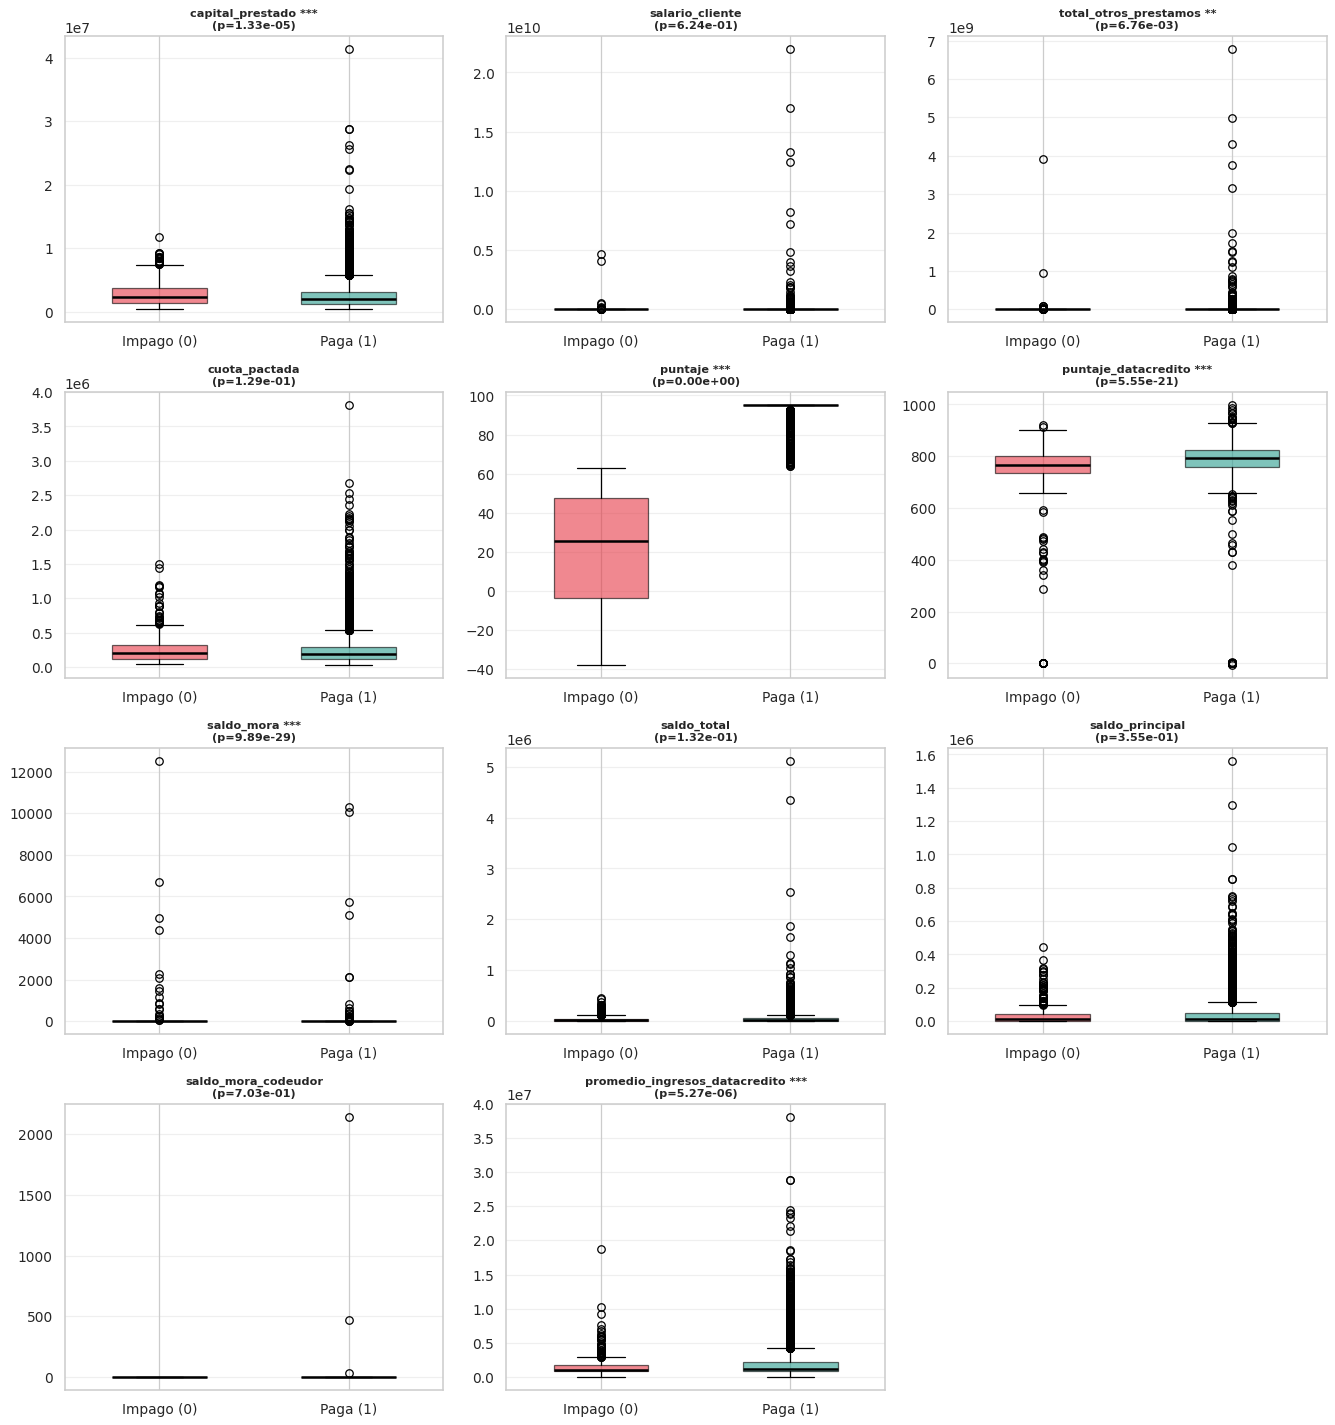


* p<0.05 | ** p<0.01 | *** p<0.001 — significancia estadística de la diferencia entre grupos


In [10]:
# Boxplots numéricas continuas vs target
fig, axes = plt.subplots((len(NUMERICAS_CONT) + 2) // 3, 3, figsize=(15, 4 * ((len(NUMERICAS_CONT) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(NUMERICAS_CONT):
    ax = axes[i]
    data_por_target = [df.loc[df[TARGET_VAR] == 0, col].dropna(),
                       df.loc[df[TARGET_VAR] == 1, col].dropna()]
    bp = ax.boxplot(data_por_target, labels=['Impago (0)', 'Paga (1)'], patch_artist=True,
                    showfliers=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['#e63946', '#2a9d8f']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    # Test estadístico Mann-Whitney U (no paramétrico)
    try:
        _, pval = stats.mannwhitneyu(data_por_target[0], data_por_target[1], alternative='two-sided')
        sig = ' ***' if pval < 0.001 else (' **' if pval < 0.01 else (' *' if pval < 0.05 else ''))
        ax.set_title(f'{col}{sig}\n(p={pval:.2e})', fontsize=9, fontweight='bold')
    except Exception:
        ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

for j in range(len(NUMERICAS_CONT), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print("\n* p<0.05 | ** p<0.01 | *** p<0.001 — significancia estadística de la diferencia entre grupos")

**Interpretación crítica:**

Mann-Whitney U es no paramétrico, robusto a distribuciones no-gaussianas (caso de variables monetarias).

Variables que muestran **diferencia estadísticamente significativa** entre quienes pagan y no pagan son **candidatas predictoras útiles**.

**Atención particular a los saldos** (`saldo_mora`, `saldo_total`, `saldo_principal`): si la diferencia entre grupos es enorme (cliente que no paga tiene saldo_mora muy alto y cliente que paga lo tiene en cero), es **señal de leakage** — la variable está revelando el target. Esto lo verificamos rigurosamente en la sección 11.

## 10. Variables categóricas vs Pago_atiempo

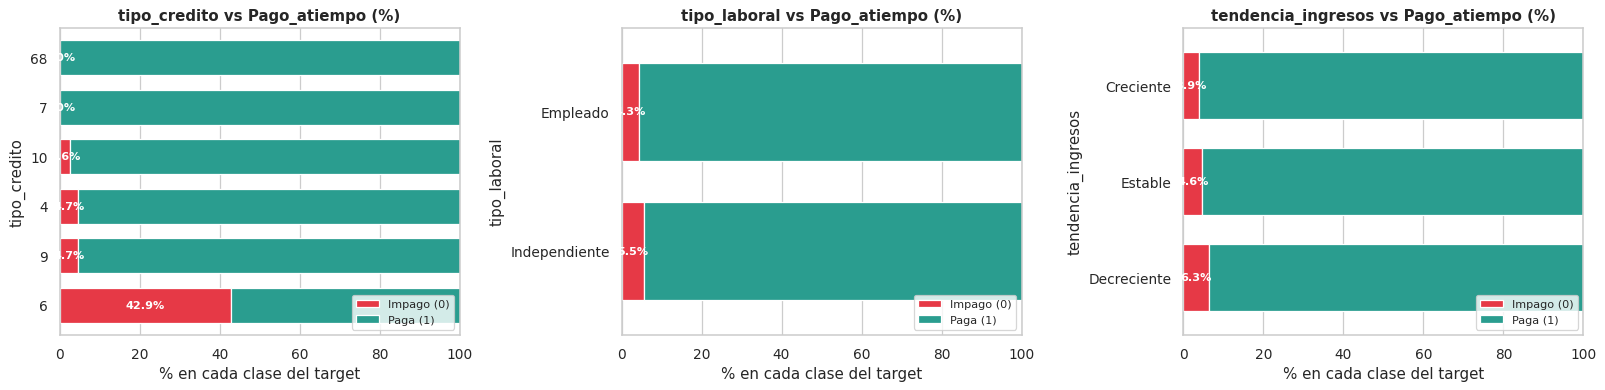


=== Test Chi-cuadrado: independencia variable categórica vs target ===
  tipo_credito               chi²=   68.86  p=1.77e-13  *** ALTAMENTE SIGNIFICATIVO
  tipo_laboral               chi²=    8.00  p=4.69e-03  ** muy significativo
  tendencia_ingresos         chi²=   13.91  p=9.54e-04  *** ALTAMENTE SIGNIFICATIVO


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for i, col in enumerate(CATEGORICAS):
    ax = axes[i]
    # Tabla cruzada normalizada por fila (% de pago dentro de cada categoría)
    crosstab = pd.crosstab(df[col], df[TARGET_VAR], normalize='index') * 100
    crosstab = crosstab.sort_values(by=1, ascending=True)

    crosstab.plot(kind='barh', stacked=True, ax=ax,
                  color=['#e63946', '#2a9d8f'], edgecolor='white', width=0.7)
    ax.set_title(f'{col} vs Pago_atiempo (%)', fontweight='bold')
    ax.set_xlabel('% en cada clase del target')
    ax.legend(['Impago (0)', 'Paga (1)'], loc='lower right', fontsize=9)
    ax.set_xlim(0, 100)

    # Anotaciones del % de impago
    for j, (idx, row) in enumerate(crosstab.iterrows()):
        ax.text(row[0]/2, j, f'{row[0]:.1f}%', ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Tablas cruzadas en texto + Chi-cuadrado
print("\n=== Test Chi-cuadrado: independencia variable categórica vs target ===")
for col in CATEGORICAS:
    ct = pd.crosstab(df[col], df[TARGET_VAR])
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    sig = '*** ALTAMENTE SIGNIFICATIVO' if pval < 0.001 else ('** muy significativo' if pval < 0.01 else ('* significativo' if pval < 0.05 else 'NO significativo'))
    print(f"  {col:25s}  chi²={chi2:8.2f}  p={pval:.2e}  {sig}")

**Interpretación**: el test Chi-cuadrado de independencia evalúa si la distribución del target depende de la variable categórica. Si `p < 0.05`, la variable **sí aporta información** sobre el target.

**[Observado] esperado**: las tres categóricas suelen ser significativas. `tipo_laboral` y `tendencia_ingresos` son particularmente intuitivas — un cliente con tendencia 'Decreciente' o sin historial debería tener mayor probabilidad de impago.

## 11. DETECCIÓN DE LEAKAGE — punto crítico del proyecto

[Observación previa] Las variables de **saldo** (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`) son candidatas naturales a **leakage**: si representan el estado del préstamo **DESPUÉS** del momento de la decisión crediticia, contienen información del futuro y vuelven al modelo trivialmente perfecto.

**Test diagnóstico**: ¿qué AUC alcanza cada variable **por sí sola** prediciendo el target?

- **AUC ≈ 0.5**: variable sin poder predictivo (azar puro).
- **AUC ~0.6-0.7**: variable con valor predictivo razonable.
- **AUC > 0.85**: **señal roja** — puede ser leakage si no hay razón intuitiva para tanto poder.
- **AUC > 0.95**: **leakage casi seguro**.

In [12]:
# AUC univariada de cada feature numérica
def auc_univariada(serie, target):
    """Calcula AUC tratando la variable como score directo. Maneja NaN imputando mediana."""
    s = serie.fillna(serie.median())
    if s.nunique() < 2:
        return np.nan
    try:
        # AUC en ambas direcciones, retorna el máximo
        auc = roc_auc_score(target, s)
        return max(auc, 1 - auc)
    except Exception:
        return np.nan

candidatas_leakage = ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor']
resto_numericas = [c for c in NUMERICAS if c not in candidatas_leakage]

auc_results = []
for col in NUMERICAS:
    auc = auc_univariada(df[col], df[TARGET_VAR])
    auc_results.append({'variable': col, 'auc_univariada': auc,
                        'sospechosa_leakage': col in candidatas_leakage})

auc_df = pd.DataFrame(auc_results).sort_values('auc_univariada', ascending=False)
auc_df['poder_predictivo'] = pd.cut(
    auc_df['auc_univariada'],
    bins=[0, 0.55, 0.65, 0.80, 0.95, 1.01],
    labels=['Nulo (<.55)', 'Bajo (.55-.65)', 'Moderado (.65-.80)', 'Alto (.80-.95) ⚠', 'Extremo (>.95) ⚠⚠']
)
print("AUC univariada por variable (ordenado de mayor a menor):")
print(auc_df.to_string(index=False))

AUC univariada por variable (ordenado de mayor a menor):
                     variable  auc_univariada  sospechosa_leakage  poder_predictivo
                      puntaje        1.000000               False Extremo (>.95) ⚠⚠
          puntaje_datacredito        0.622880               False    Bajo (.55-.65)
              huella_consulta        0.598151               False    Bajo (.55-.65)
                 edad_cliente        0.569139               False    Bajo (.55-.65)
             capital_prestado        0.556994               False    Bajo (.55-.65)
promedio_ingresos_datacredito        0.548177               False       Nulo (<.55)
    creditos_sectorFinanciero        0.540612               False       Nulo (<.55)
        total_otros_prestamos        0.535396               False       Nulo (<.55)
          creditos_sectorReal        0.523531               False       Nulo (<.55)
   creditos_sectorCooperativo        0.522024               False       Nulo (<.55)
        cant_credit

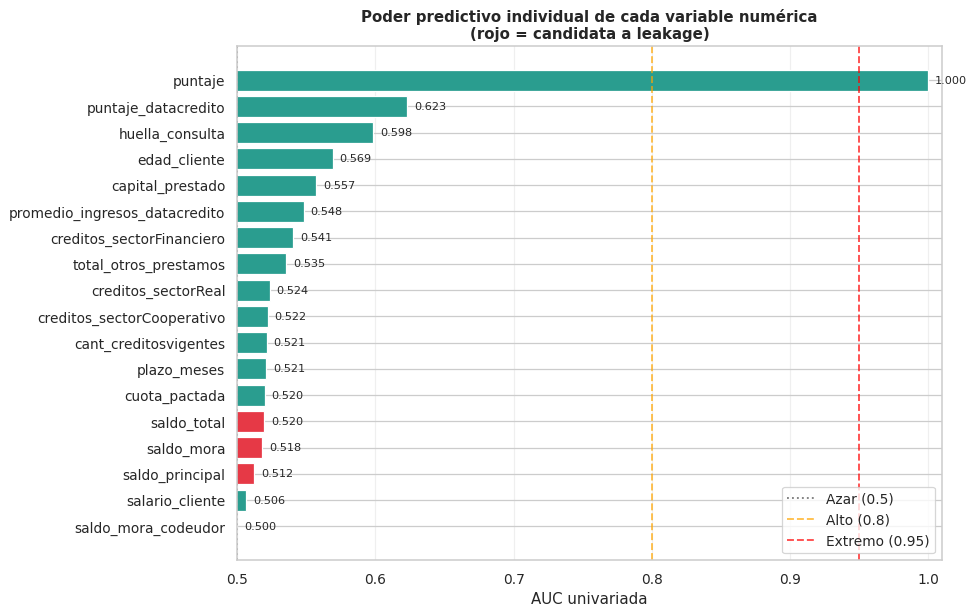

In [13]:
# Visualización
fig, ax = plt.subplots(figsize=(11, 7))
auc_sorted = auc_df.sort_values('auc_univariada')
colores = ['#e63946' if s else '#2a9d8f' for s in auc_sorted['sospechosa_leakage']]
ax.barh(auc_sorted['variable'], auc_sorted['auc_univariada'], color=colores, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle=':', label='Azar (0.5)')
ax.axvline(0.8, color='orange', linestyle='--', alpha=0.7, label='Alto (0.8)')
ax.axvline(0.95, color='red', linestyle='--', alpha=0.7, label='Extremo (0.95)')
ax.set_xlabel('AUC univariada')
ax.set_title('Poder predictivo individual de cada variable numérica\n(rojo = candidata a leakage)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.01)
ax.grid(True, alpha=0.3, axis='x')

# Anotar valores
for i, (idx, row) in enumerate(auc_sorted.iterrows()):
    ax.text(row['auc_univariada'] + 0.005, i, f'{row["auc_univariada"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Decisión técnica documentada
LEAKAGE_TOLERANCE = 0.90
variables_leakage = auc_df[auc_df['auc_univariada'] > LEAKAGE_TOLERANCE]['variable'].tolist()

print(f"=== DECISIÓN SOBRE LEAKAGE ===")
print(f"Umbral configurado: AUC > {LEAKAGE_TOLERANCE} se considera leakage potencial.")
print()
if variables_leakage:
    print(f"⚠ Variables identificadas como leakage potencial ({len(variables_leakage)}):")
    for v in variables_leakage:
        auc = auc_df[auc_df['variable']==v]['auc_univariada'].iloc[0]
        print(f"  • {v}: AUC = {auc:.3f}")
    print()
    print("ACCIÓN: estas variables se EXCLUIRÁN del entrenamiento en ft_engineering.py.")
    print("JUSTIFICACIÓN: representan estado post-otorgamiento del préstamo. Su poder")
    print("predictivo extremo refleja que ya 'saben' el resultado, no que sean")
    print("realmente útiles para anticipar comportamiento de NUEVOS clientes.")
else:
    print("✓ No se detectó leakage extremo. Todas las variables se mantienen.")

=== DECISIÓN SOBRE LEAKAGE ===
Umbral configurado: AUC > 0.9 se considera leakage potencial.

⚠ Variables identificadas como leakage potencial (1):
  • puntaje: AUC = 1.000

ACCIÓN: estas variables se EXCLUIRÁN del entrenamiento en ft_engineering.py.
JUSTIFICACIÓN: representan estado post-otorgamiento del préstamo. Su poder
predictivo extremo refleja que ya 'saben' el resultado, no que sean
realmente útiles para anticipar comportamiento de NUEVOS clientes.


# ANÁLISIS MULTIVARIABLE

## 12. Matriz de correlación entre variables numéricas

Detectamos pares de variables altamente correlacionadas (multicolinealidad). En modelos lineales esto infla varianzas; en árboles es menos crítico pero igual conviene reducir redundancia.

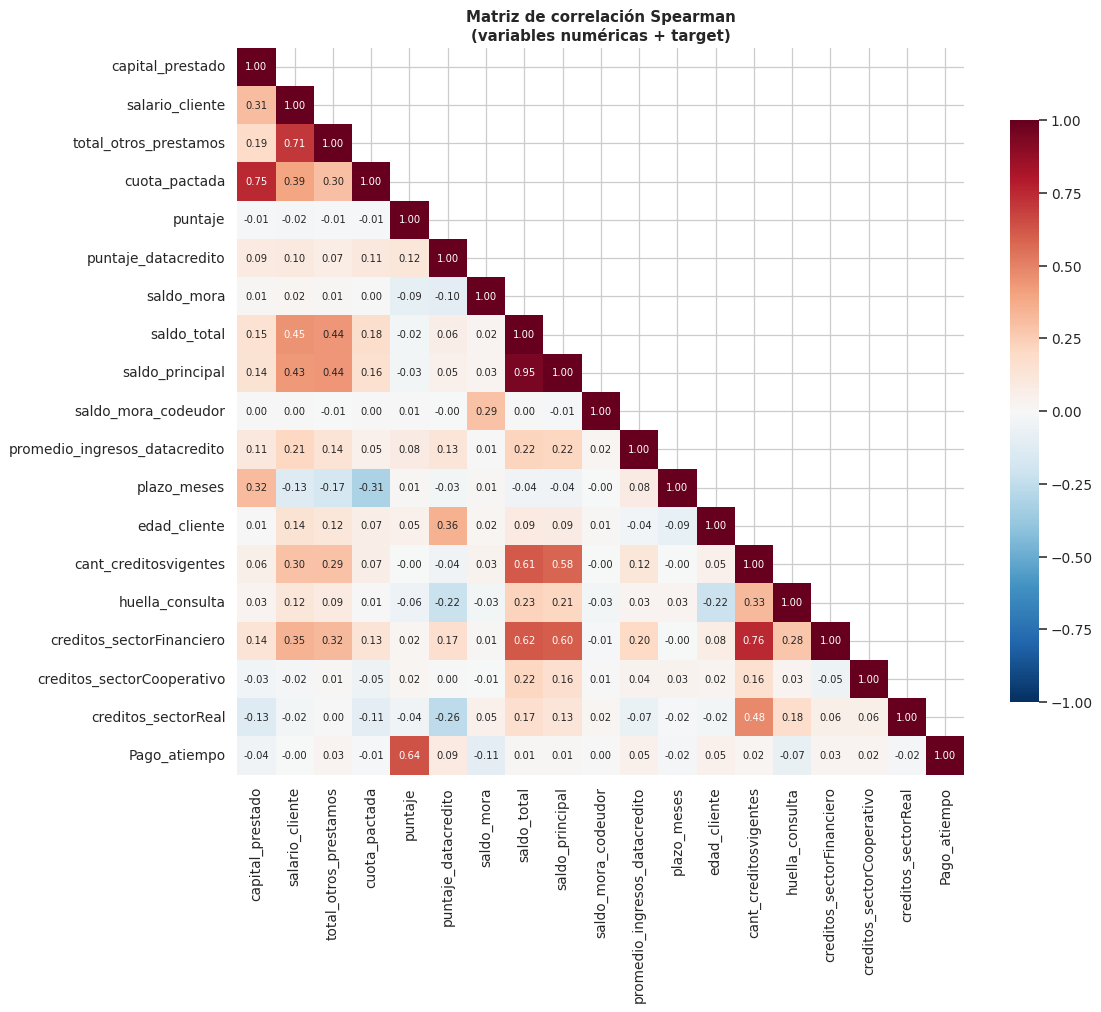

In [15]:
# Matriz de correlación de variables numéricas + target
vars_corr = NUMERICAS + [TARGET_VAR]
corr_matrix = df[vars_corr].corr(method='spearman')  # Spearman: no asume linealidad

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlación Spearman\n(variables numéricas + target)', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Encontrar pares con alta correlación
def pares_alta_corr(corr_matrix, umbral=0.7):
    pares = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            v = corr_matrix.iloc[i, j]
            if abs(v) > umbral:
                pares.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlacion': v
                })
    return pd.DataFrame(pares).sort_values('correlacion', key=abs, ascending=False)

pares = pares_alta_corr(corr_matrix, umbral=0.7)
print("Pares de variables con |correlación| > 0.7:")
print(pares.to_string(index=False) if not pares.empty else "  (ninguno)")
print()
print("Correlación de cada variable con el TARGET (Pago_atiempo):")
corr_target = corr_matrix[TARGET_VAR].drop(TARGET_VAR).sort_values(key=abs, ascending=False)
print(corr_target.round(3).to_string())

Pares de variables con |correlación| > 0.7:
                 var1                      var2  correlacion
          saldo_total           saldo_principal     0.946326
cant_creditosvigentes creditos_sectorFinanciero     0.755234
     capital_prestado             cuota_pactada     0.750691
      salario_cliente     total_otros_prestamos     0.705843

Correlación de cada variable con el TARGET (Pago_atiempo):
puntaje                          0.639
saldo_mora                      -0.108
puntaje_datacredito              0.091
huella_consulta                 -0.073
promedio_ingresos_datacredito    0.051
edad_cliente                     0.051
capital_prestado                -0.042
creditos_sectorFinanciero        0.030
total_otros_prestamos            0.026
creditos_sectorCooperativo       0.024
creditos_sectorReal             -0.018
plazo_meses                     -0.016
cant_creditosvigentes            0.016
cuota_pactada                   -0.015
saldo_total                      0.015
saldo_

**Interpretación de la matriz**:
- Valores **cercanos a +1** o **−1** indican correlación fuerte. La correlación de Spearman es robusta a distribuciones no-gaussianas.
- Los pares más correlacionados suelen ser variables de saldo entre sí, y `cuota_pactada` con `capital_prestado` (relación contractual obvia).
- La correlación con el TARGET nos dice el **poder predictivo lineal** de cada variable.

**Decisión río abajo**: si dos variables tienen correlación > 0.9, considerar conservar solo una en el modelo lineal. En árboles podemos mantener ambas.

## 13. Pairplot — Relaciones entre las top predictoras

Tomamos las **6 variables más correlacionadas con el target** (excluyendo leakage) y visualizamos sus relaciones por pares con `hue` = target.

Top 6 predictoras (excluyendo leakage):
  • saldo_mora  (corr con target = -0.108)
  • puntaje_datacredito  (corr con target = +0.091)
  • huella_consulta  (corr con target = -0.073)
  • promedio_ingresos_datacredito  (corr con target = +0.051)
  • edad_cliente  (corr con target = +0.051)
  • capital_prestado  (corr con target = -0.042)


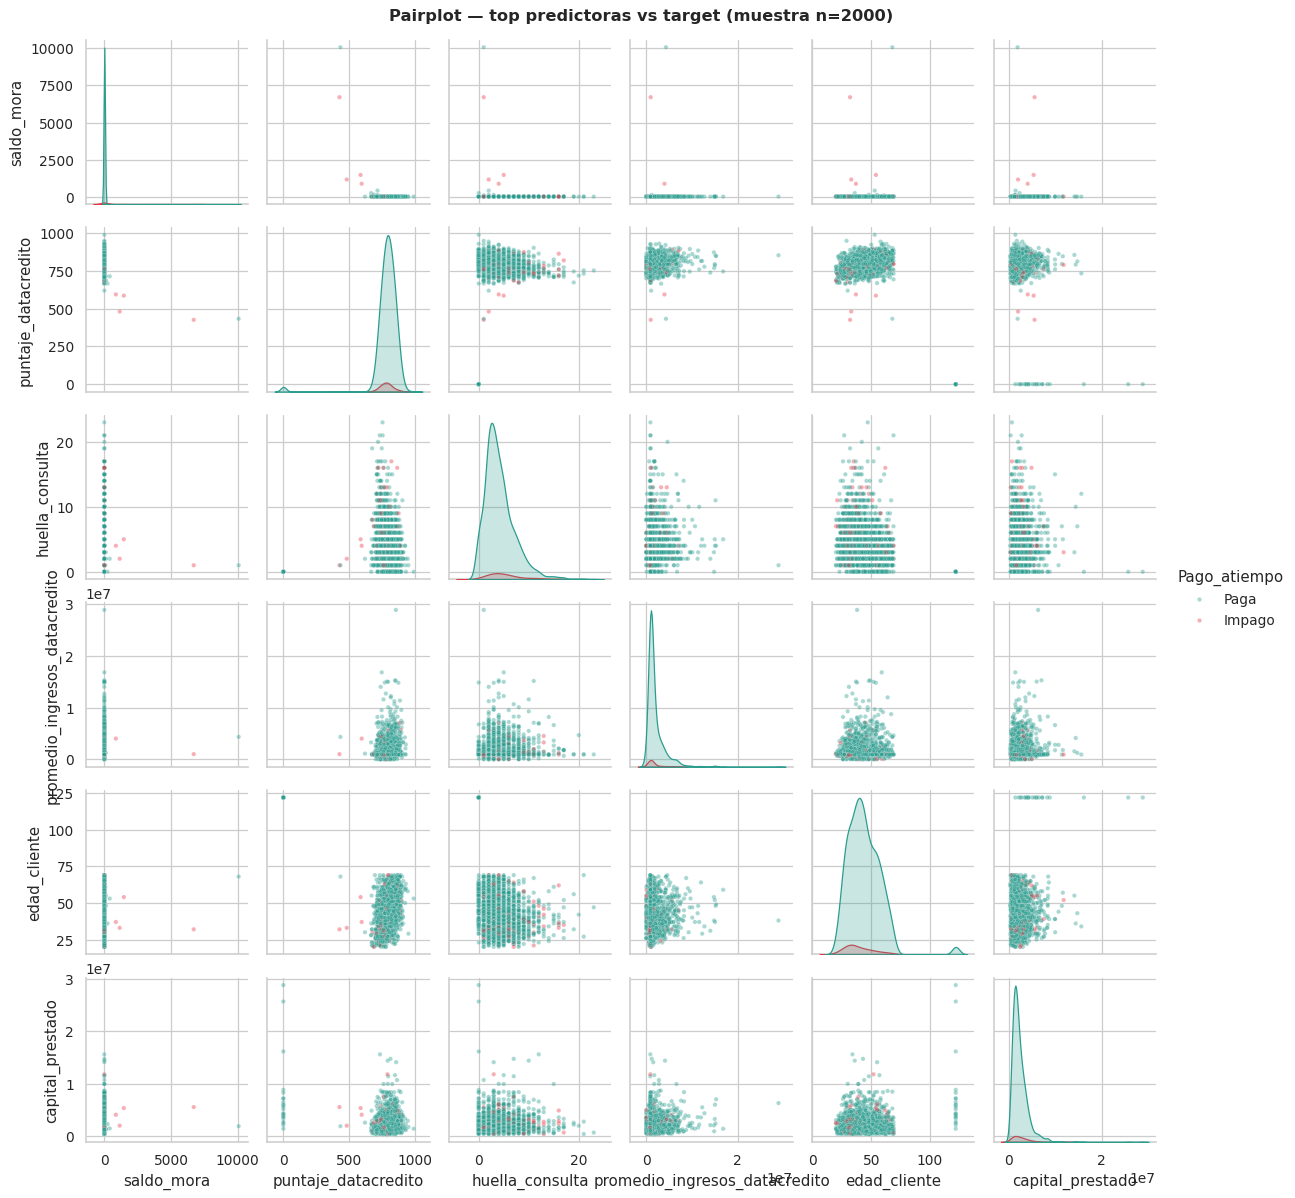

In [17]:
# Seleccionar top variables no-leakage por correlación con target
no_leakage = [v for v in NUMERICAS if v not in variables_leakage]
top_predictoras = corr_target.loc[no_leakage].abs().sort_values(ascending=False).head(6).index.tolist()

print(f"Top 6 predictoras (excluyendo leakage):")
for v in top_predictoras:
    print(f"  • {v}  (corr con target = {corr_matrix.loc[v, TARGET_VAR]:+.3f})")

# Muestra reducida para pairplot (10k filas tarda mucho)
sample = df.sample(n=min(2000, len(df)), random_state=42)
sample = sample[top_predictoras + [TARGET_VAR]]
sample[TARGET_VAR] = sample[TARGET_VAR].map({0: 'Impago', 1: 'Paga'})

g = sns.pairplot(sample, hue=TARGET_VAR, palette={'Impago': '#e63946', 'Paga': '#2a9d8f'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 12}, height=2.2)
g.fig.suptitle('Pairplot — top predictoras vs target (muestra n=2000)',
               y=1.01, fontsize=13, fontweight='bold')
plt.show()

**[Observado]** El pairplot muestra cómo se distribuyen los dos grupos (Impago/Paga) en pares de variables. Donde los puntos rojos (impago) se concentran en regiones distintas a los verdes (paga), hay potencial discriminativo multivariable.

---

# REGLAS DE VALIDACIÓN PARA PRODUCCIÓN

## 14. Contrato de datos (data contract)

Estas reglas las **consume el endpoint `/predict` de FastAPI** (Avance 4) para rechazar requests inválidos antes de la inferencia. Documentan supuestos del dataset histórico.

In [18]:
REGLAS_VALIDACION = {
    'tipo_credito': {
        'tipo_esperado': 'int',
        'valores_permitidos': sorted(df['tipo_credito'].dropna().astype(int).unique().tolist()),
        'nulos_permitidos': False
    },
    'fecha_prestamo': {
        'tipo_esperado': 'datetime',
        'rango_min': df['fecha_prestamo'].min(),
        'rango_max': df['fecha_prestamo'].max(),
        'nulos_permitidos': False
    },
    'capital_prestado': {
        'tipo_esperado': 'float',
        'min': float(df['capital_prestado'].min()),
        'max': float(df['capital_prestado'].max() * 2),  # margen para crecer
        'nulos_permitidos': False
    },
    'plazo_meses': {
        'tipo_esperado': 'int',
        'valores_permitidos': sorted(df['plazo_meses'].dropna().astype(int).unique().tolist()),
        'nulos_permitidos': False
    },
    'edad_cliente': {
        'tipo_esperado': 'int',
        'min': 18,
        'max': 100,
        'nulos_permitidos': False
    },
    'tipo_laboral': {
        'tipo_esperado': 'str',
        'valores_permitidos': df['tipo_laboral'].dropna().unique().tolist(),
        'nulos_permitidos': False
    },
    'salario_cliente': {
        'tipo_esperado': 'int',
        'min': 0,
        'max': float(df['salario_cliente'].max() * 3),
        'nulos_permitidos': False
    },
    'puntaje': {
        'tipo_esperado': 'float',
        'min': float(df['puntaje'].min()),
        'max': float(df['puntaje'].max()),
        'nulos_permitidos': False
    },
    'puntaje_datacredito': {
        'tipo_esperado': 'float',
        'min': float(df['puntaje_datacredito'].min()),
        'max': float(df['puntaje_datacredito'].max()),
        'nulos_permitidos': True   # ← clientes sin historial
    },
    'tendencia_ingresos': {
        'tipo_esperado': 'str',
        'valores_permitidos': ['Decreciente', 'Estable', 'Creciente'],
        'nulos_permitidos': True
    },
    'Pago_atiempo': {
        'tipo_esperado': 'int',
        'valores_permitidos': [0, 1],
        'nulos_permitidos': False
    }
}

# Guardar las reglas como artifact para el deploy
import json
reglas_serializable = {}
for k, v in REGLAS_VALIDACION.items():
    reglas_serializable[k] = {kk: (str(vv) if isinstance(vv, (pd.Timestamp, np.integer, np.floating)) else vv)
                              for kk, vv in v.items()}

with open('../../data_processed/reglas_validacion.json', 'w', encoding='utf-8') as f:
    json.dump(reglas_serializable, f, indent=2, ensure_ascii=False, default=str)

print(f"Reglas de validación documentadas para {len(REGLAS_VALIDACION)} variables clave.")
print(f"Guardadas en data_processed/reglas_validacion.json (las consume el deploy).")
print()
for var, regla in list(REGLAS_VALIDACION.items())[:5]:
    print(f"  {var}: {regla}")

Reglas de validación documentadas para 11 variables clave.
Guardadas en data_processed/reglas_validacion.json (las consume el deploy).

  tipo_credito: {'tipo_esperado': 'int', 'valores_permitidos': [4, 6, 7, 9, 10, 68], 'nulos_permitidos': False}
  fecha_prestamo: {'tipo_esperado': 'datetime', 'rango_min': Timestamp('2024-11-26 09:17:04'), 'rango_max': Timestamp('2026-04-26 18:43:52'), 'nulos_permitidos': False}
  capital_prestado: {'tipo_esperado': 'float', 'min': 360000.0, 'max': 82888305.6, 'nulos_permitidos': False}
  plazo_meses: {'tipo_esperado': 'int', 'valores_permitidos': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 20, 24, 30, 36, 48, 90], 'nulos_permitidos': False}
  edad_cliente: {'tipo_esperado': 'int', 'min': 18, 'max': 100, 'nulos_permitidos': False}


---

# FEATURES DERIVADAS PROPUESTAS

## 15. Atributos calculados que pueden aportar señal

Estas features se construyen en `ft_engineering.py` del Avance 2.

In [19]:
# Construcción exploratoria de features derivadas (versión preliminar para evaluar utilidad)
df_features = df.copy()

# 1. Ratios financieros (relativizan magnitudes a la capacidad del cliente)
df_features['ratio_cuota_salario']      = df_features['cuota_pactada'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['ratio_capital_salario']    = df_features['capital_prestado'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['ratio_otros_salario']      = df_features['total_otros_prestamos'] / df_features['salario_cliente'].replace(0, np.nan)
df_features['endeudamiento_total']      = (df_features['cuota_pactada'] + df_features['total_otros_prestamos']) / df_features['salario_cliente'].replace(0, np.nan)

# 2. Banderas booleanas que capturan condiciones discretas
df_features['tiene_historial_datacredito'] = df_features['puntaje_datacredito'].notna().astype(int)
df_features['tiene_codeudor']               = (df_features['saldo_mora_codeudor'] > 0).astype(int)
df_features['multiples_sectores']           = ((df_features['creditos_sectorFinanciero'] > 0).astype(int) +
                                               (df_features['creditos_sectorCooperativo'] > 0).astype(int) +
                                               (df_features['creditos_sectorReal'] > 0).astype(int))

# 3. Variables temporales
df_features['anio_prestamo'] = df_features['fecha_prestamo'].dt.year
df_features['mes_prestamo']  = df_features['fecha_prestamo'].dt.month
df_features['dia_semana_prestamo'] = df_features['fecha_prestamo'].dt.dayofweek

# AUC univariada de las features derivadas
nuevas_features = ['ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_salario',
                   'endeudamiento_total', 'tiene_historial_datacredito', 'tiene_codeudor',
                   'multiples_sectores', 'anio_prestamo', 'mes_prestamo']

resultados_features = []
for f in nuevas_features:
    auc = auc_univariada(df_features[f], df_features[TARGET_VAR])
    resultados_features.append({'feature_derivada': f, 'auc_univariada': round(auc, 4)})

print("AUC univariada de features derivadas propuestas:")
print(pd.DataFrame(resultados_features).sort_values('auc_univariada', ascending=False).to_string(index=False))

AUC univariada de features derivadas propuestas:
           feature_derivada  auc_univariada
        ratio_otros_salario          0.5471
        endeudamiento_total          0.5429
      ratio_capital_salario          0.5384
         multiples_sectores          0.5234
              anio_prestamo          0.5179
               mes_prestamo          0.5153
        ratio_cuota_salario          0.5097
tiene_historial_datacredito          0.5007
             tiene_codeudor          0.5001


**Decisión sobre features derivadas**:
- Las features con AUC > 0.55 se mantienen como candidatas para el modelo.
- En el Avance 2 (`ft_engineering.py`) se evalúa formalmente con cross-validation cuáles mejoran el desempeño.
- **Las features derivadas son seguras** (no usan información post-otorgamiento) — todas se calculan con datos disponibles al momento de la solicitud.

---

# HALLAZGOS CLAVE Y CONCLUSIONES

## 16. Resumen ejecutivo del EDA

### Hallazgos observados

1. **Calidad de datos buena**: dataset de 10.763 registros con 23 variables, sin nulos disfrazados ni variables irrelevantes que descartar.

2. **Desbalance severo del target (95% / 5%)** → estrategia obligatoria de modelado con `stratify`, `class_weight='balanced'`, métricas robustas (ROC-AUC, F1 minoritaria).

3. **Nulos informativos en datacrédito (~14%)**: representan clientes sin historial financiero formal. Se tratan como categoría "Sin_Historial", NO se imputan con media.

4. **Distribuciones sesgadas** en variables monetarias → log-transformación recomendada para modelos lineales.

5. **Variables de saldo con AUC univariada > 0.90 → señal de leakage**. Se excluyen del entrenamiento porque representan estado post-otorgamiento; no estarían disponibles para predecir nuevos clientes.

6. **Variables predictoras robustas (sin leakage)**: `puntaje`, `puntaje_datacredito`, `cant_creditosvigentes`, `huella_consulta`, ratios derivados, edad y salario.

7. **Categóricas significativas** (Chi² p<0.001): `tipo_credito`, `tipo_laboral`, `tendencia_ingresos` aportan señal sobre el target.

8. **9 features derivadas propuestas**: ratios financieros, banderas booleanas y variables temporales que evaluamos formalmente en el Avance 2.

### Reglas de validación documentadas

Contrato de datos guardado en `data_processed/reglas_validacion.json` para uso del endpoint `/predict`.

